# 🛡️ ToxicGuard — Colab Notebook (Local Runtime)
**FAZ 4: Model Değerlendirme + FAZ 1: EDA Grafikleri**

Bu notebook VS Code Colab extension'ı ile **yerel bilgisayara bağlı** çalışır.  
Google Drive mount'a gerek yok — dosyalar doğrudan `mezuniyet_proje/` klasöründen okunur ve oraya yazılır.

In [8]:
# ================================================
# HÜCRE 1 — Proje Yolu Ayarla
# ================================================
import os
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/ToxicGuard'  # Drive'da oluşturduğun klasör
MODELS_DIR  = os.path.join(BASE, 'models')
DATA_DIR    = os.path.join(BASE, 'data')
RESULTS_DIR = os.path.join(BASE, 'reports', 'model_results')
EDA_DIR     = os.path.join(BASE, 'reports', 'eda_plots')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(EDA_DIR, exist_ok=True)
print("✅ Drive bağlandı!")


Mounted at /content/drive
✅ Drive bağlandı!


In [9]:
# ================================================
# HÜCRE 2 — Kütüphaneleri Kur (ilk çalıştırmada)
# ================================================
!pip install xgboost scikit-learn matplotlib seaborn wordcloud nltk joblib --quiet

import nltk
nltk.download('stopwords', quiet=True)
print('✅ Kütüphaneler hazır!')

✅ Kütüphaneler hazır!


In [10]:
# ================================================
# HÜCRE 3 — İmportlar ve Sabitler
# ================================================
import json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score
)

LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
LABEL_TR   = {
    'toxic': 'Toksik', 'severe_toxic': 'Ağır Toksik', 'obscene': 'Müstehcen',
    'threat': 'Tehdit', 'insult': 'Hakaret', 'identity_hate': 'Kimlik Nefreti'
}
STOP_WORDS = set(stopwords.words('english'))
sns.set_theme(style='darkgrid', palette='muted')

print('✅ Hazır!')

✅ Hazır!


In [11]:
# ================================================
# HÜCRE 4 — Test Verisi ve Modelleri Yükle
# ================================================
print('📦 Test verisi yükleniyor...')
X_test = joblib.load(os.path.join(DATA_DIR, 'X_test.pkl'))
y_test = joblib.load(os.path.join(DATA_DIR, 'y_test.pkl'))
print(f'   X_test: {X_test.shape},  y_test: {y_test.shape}')

MODEL_FILES = {
    'Logistic Regression': 'logistic_regression.pkl',
    'SVM':                 'svm_model.pkl',
    'XGBoost':             'xgboost_model.pkl',
}

# Random Forest varsa ekle (büyük dosya, yüklenmesi uzun sürer)
rf_path = os.path.join(MODELS_DIR, 'random_forest.pkl')
if os.path.exists(rf_path):
    MODEL_FILES['Random Forest'] = 'random_forest.pkl'
    print('   Random Forest bulundu, eklendi.')
else:
    print('   ⚠️ random_forest.pkl bulunamadı, atlanıyor.')

print('\n🤖 Modeller yükleniyor...')
models = {}
for name, fname in MODEL_FILES.items():
    path = os.path.join(MODELS_DIR, fname)
    if os.path.exists(path):
        models[name] = joblib.load(path)
        print(f'   ✅ {name}')
    else:
        print(f'   ❌ {name} bulunamadı: {path}')

print(f'\nToplam {len(models)} model yüklendi.')

📦 Test verisi yükleniyor...
   X_test: (31897, 50000),  y_test: (31897, 6)
   Random Forest bulundu, eklendi.

🤖 Modeller yükleniyor...
   ✅ Logistic Regression
   ✅ SVM
   ✅ XGBoost
   ✅ Random Forest

Toplam 4 model yüklendi.


In [12]:
# ================================================
# HÜCRE 5 — FAZ 4: Model Değerlendirme
# ================================================
all_results = []

for model_name, model in models.items():
    print(f'\n🔍 {model_name} değerlendiriliyor...')
    start = time.time()

    y_pred = model.predict(X_test)

    # Olasılık skoru (SVM için decision_function)
    try:
        y_prob = model.predict_proba(X_test)
    except AttributeError:
        df_vals = model.decision_function(X_test)
        y_prob = 1 / (1 + np.exp(-df_vals))

    elapsed = time.time() - start

    f1_micro   = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_macro   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_test, y_prob, average='macro', multi_class='ovr')
    except Exception:
        auc = 0.0

    y_test_arr = np.array(y_test)
    per_label = {
        col: {
            'f1':        round(f1_score(y_test_arr[:, i], y_pred[:, i], zero_division=0), 4),
            'precision': round(precision_score(y_test_arr[:, i], y_pred[:, i], zero_division=0), 4),
            'recall':    round(recall_score(y_test_arr[:, i], y_pred[:, i], zero_division=0), 4),
        }
        for i, col in enumerate(LABEL_COLS)
    }

    result = {
        'model':      model_name,
        'f1_micro':   round(f1_micro, 4),
        'f1_macro':   round(f1_macro, 4),
        'precision':  round(prec_macro, 4),
        'recall':     round(rec_macro, 4),
        'roc_auc':    round(auc, 4),
        'eval_time_s':round(elapsed, 1),
        'per_label':  per_label
    }
    all_results.append(result)
    print(f'   F1 Micro: {f1_micro:.4f}  |  F1 Macro: {f1_macro:.4f}  |  ROC-AUC: {auc:.4f}  |  Süre: {elapsed:.1f}s')

print('\n✅ Değerlendirme tamamlandı!')


🔍 Logistic Regression değerlendiriliyor...
   F1 Micro: 0.6830  |  F1 Macro: 0.5643  |  ROC-AUC: 0.9816  |  Süre: 0.1s

🔍 SVM değerlendiriliyor...
   F1 Micro: 0.7038  |  F1 Macro: 0.5187  |  ROC-AUC: 0.9731  |  Süre: 0.2s

🔍 XGBoost değerlendiriliyor...
   F1 Micro: 0.7085  |  F1 Macro: 0.5987  |  ROC-AUC: 0.9669  |  Süre: 17.0s

🔍 Random Forest değerlendiriliyor...
   F1 Micro: 0.5905  |  F1 Macro: 0.3803  |  ROC-AUC: 0.9642  |  Süre: 66.8s

✅ Değerlendirme tamamlandı!


In [13]:
# ================================================
# HÜCRE 6 — Sonuçları Kaydet (JSON + CSV)
# ================================================
json_path = os.path.join(RESULTS_DIR, 'model_comparison.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

rows = [{
    'Model':      r['model'],
    'F1 Micro':   r['f1_micro'],
    'F1 Macro':   r['f1_macro'],
    'Precision':  r['precision'],
    'Recall':     r['recall'],
    'ROC-AUC':    r['roc_auc'],
    'Süre (sn)':  r['eval_time_s'],
} for r in all_results]

df_comp = pd.DataFrame(rows).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
csv_path = os.path.join(RESULTS_DIR, 'model_comparison.csv')
df_comp.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f'✅ JSON kaydedildi → {json_path}')
print(f'✅ CSV  kaydedildi → {csv_path}')
print()
print('📊 Karşılaştırma Tablosu:')
display(df_comp)

✅ JSON kaydedildi → /content/drive/MyDrive/ToxicGuard/reports/model_results/model_comparison.json
✅ CSV  kaydedildi → /content/drive/MyDrive/ToxicGuard/reports/model_results/model_comparison.csv

📊 Karşılaştırma Tablosu:


,Model,F1 Micro,F1 Macro,Precision,Recall,ROC-AUC,Süre (sn)
0,XGBoost,0.7085,0.5987,0.5527,0.6658,0.9669,17.0
1,Logistic Regression,0.6830,0.5643,0.4520,0.8185,0.9816,0.1
2,SVM,0.7038,0.5187,0.7198,0.4230,0.9731,0.2
3,Random Forest,0.5905,0.3803,0.5275,0.3262,0.9642,66.8


In [14]:
# ================================================
# HÜCRE 7 — FAZ 1: EDA Grafiklerini Üret
# ================================================
print('📊 Temizlenmiş veri yükleniyor...')
df = pd.read_csv(os.path.join(DATA_DIR, 'gercek_temizlenmis_veri.csv'))
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
df['word_count'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))
print(f'   {len(df):,} satır yüklendi.')

📊 Temizlenmiş veri yükleniyor...
   159,484 satır yüklendi.


In [21]:
from collections import Counter

# En sık geçen 100 kelimeyi gör (toksik yorumlar)
toxic_words = ' '.join(df[df['toxic']==1]['cleaned_text'].dropna()).split()
print("TOKSIK TOP 100:")
print(Counter(toxic_words).most_common(100))

# Zararsız yorumlarda da geçen ama anlamsız kelimeler
safe_words = ' '.join(df[df['toxic']==0]['cleaned_text'].dropna().sample(10000, random_state=42)).split()
print("\nZARARSIZ TOP 100:")
print(Counter(safe_words).most_common(100))


TOKSIK TOP 100:
[('fuck', 9935), ('shit', 3621), ('like', 3512), ('wikipedia', 3433), ('nigger', 3299), ('fucking', 3289), ('suck', 3235), ('ass', 2940), ('u', 2881), ('go', 2864), ('hate', 2631), ('get', 2300), ('gay', 2238), ('know', 2201), ('page', 2145), ('die', 2082), ('faggot', 2017), ('fat', 1970), ('people', 1873), ('moron', 1862), ('bitch', 1785), ('hi', 1691), ('cunt', 1541), ('one', 1527), ('sucks', 1443), ('stupid', 1439), ('stop', 1420), ('talk', 1410), ('article', 1390), ('pig', 1355), ('jew', 1350), ('dick', 1303), ('user', 1264), ('penis', 1238), ('think', 1236), ('wiki', 1223), ('want', 1220), ('bullshit', 1139), ('life', 1088), ('block', 1088), ('time', 1062), ('asshole', 1042), ('wanker', 1035), ('dont', 1029), ('would', 1021), ('fag', 1012), ('even', 1007), ('bark', 1001), ('balls', 999), ('right', 960), ('make', 952), ('idiot', 951), ('vandalism', 950), ('going', 947), ('sex', 946), ('cock', 940), ('edit', 935), ('please', 919), ('see', 918), ('little', 851), ('pie

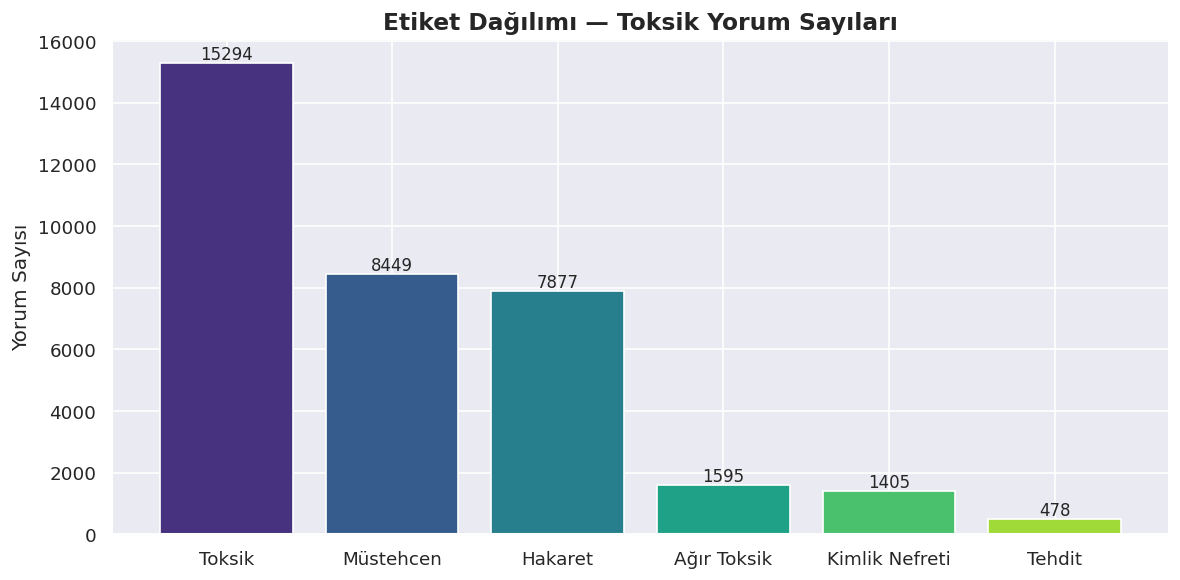

✅ 01_label_distribution.png


In [15]:
# GRAFİK 1 — Etiket Dağılımı
fig, ax = plt.subplots(figsize=(10, 5))
counts = df[LABEL_COLS].sum().sort_values(ascending=False)
bars = ax.bar([LABEL_TR[c] for c in counts.index], counts.values,
              color=sns.color_palette('viridis', len(LABEL_COLS)))
ax.bar_label(bars, fmt='%d', fontsize=10)
ax.set_title('Etiket Dağılımı — Toksik Yorum Sayıları', fontsize=14, fontweight='bold')
ax.set_ylabel('Yorum Sayısı')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '01_label_distribution.png'), bbox_inches='tight')
plt.show()
print('✅ 01_label_distribution.png')

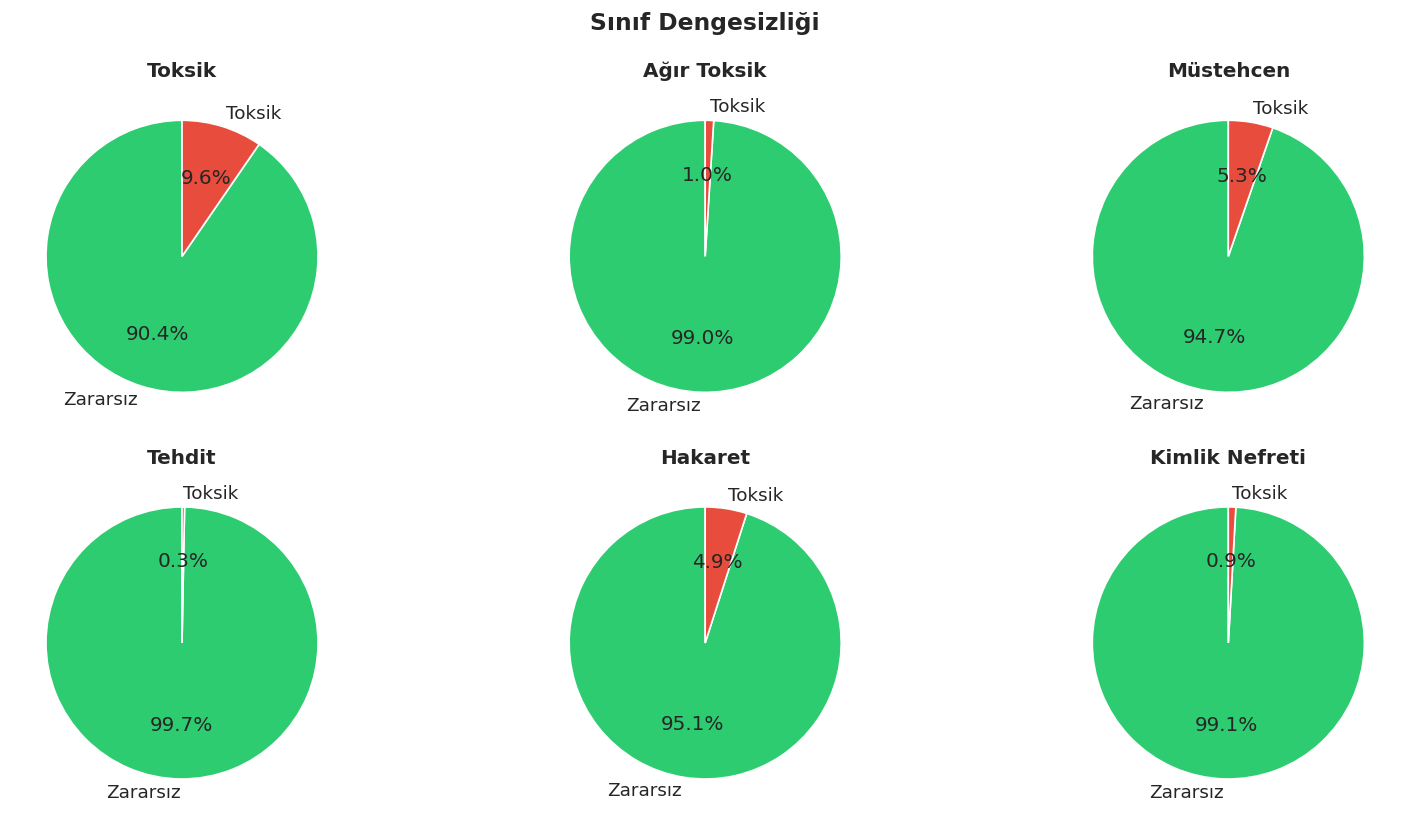

✅ 02_class_imbalance.png


In [16]:
# GRAFİK 2 — Sınıf Dengesizliği
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(LABEL_COLS):
    vc = df[col].value_counts()
    axes[i].pie(vc.values, labels=['Zararsız', 'Toksik'],
                autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
    axes[i].set_title(LABEL_TR[col], fontweight='bold')
fig.suptitle('Sınıf Dengesizliği', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '02_class_imbalance.png'), bbox_inches='tight')
plt.show()
print('✅ 02_class_imbalance.png')

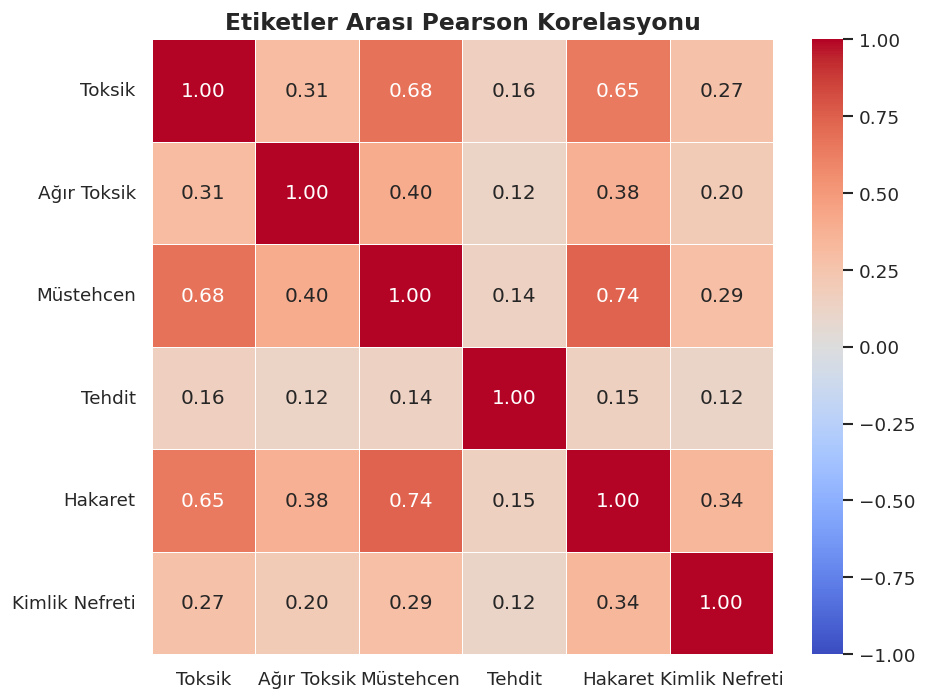

✅ 03_label_correlation.png


In [17]:
# GRAFİK 3 — Etiket Korelasyonu
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[LABEL_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=[LABEL_TR[c] for c in LABEL_COLS],
            yticklabels=[LABEL_TR[c] for c in LABEL_COLS],
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5)
ax.set_title('Etiketler Arası Pearson Korelasyonu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '03_label_correlation.png'), bbox_inches='tight')
plt.show()
print('✅ 03_label_correlation.png')

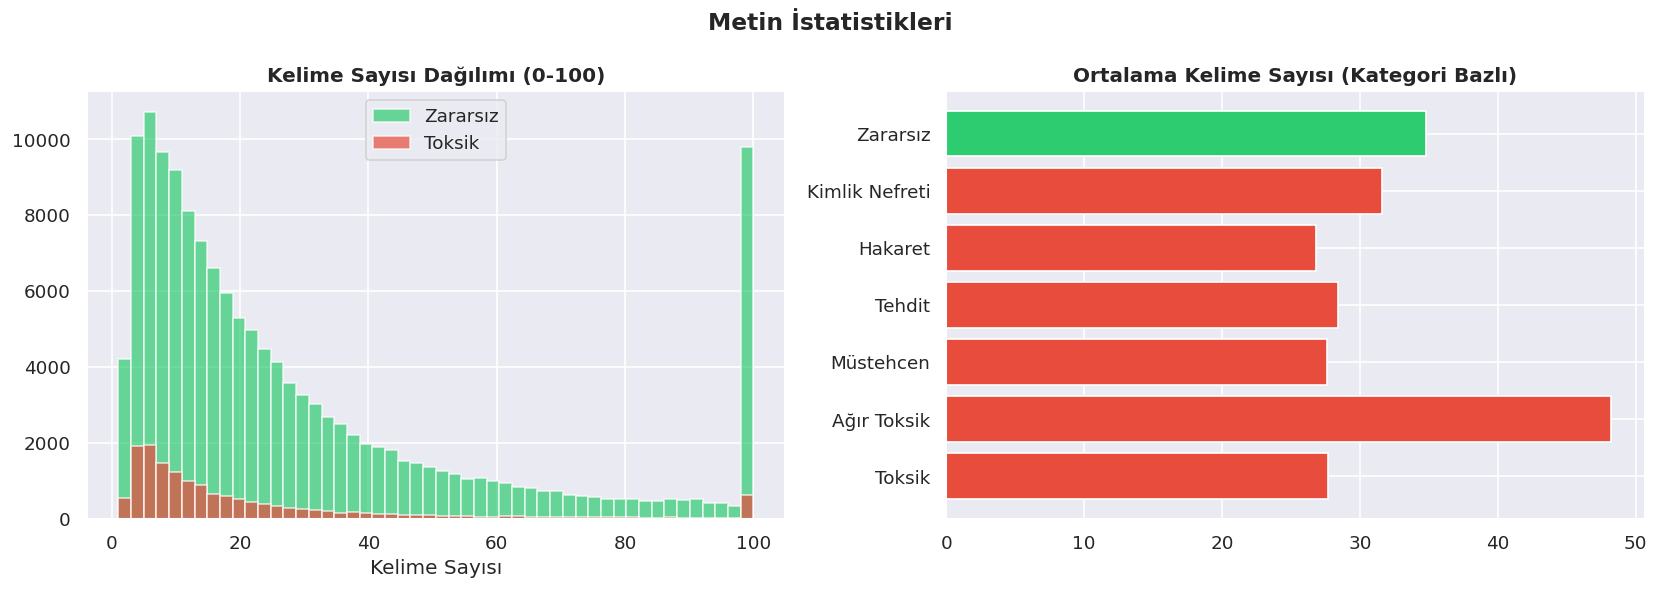

✅ 04_text_statistics.png


In [18]:
# GRAFİK 4 — Metin İstatistikleri
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['toxic']==0]['word_count'].clip(0,100), bins=50, alpha=0.7, label='Zararsız', color='#2ecc71')
axes[0].hist(df[df['toxic']==1]['word_count'].clip(0,100), bins=50, alpha=0.7, label='Toksik',   color='#e74c3c')
axes[0].set_title('Kelime Sayısı Dağılımı (0-100)', fontweight='bold')
axes[0].set_xlabel('Kelime Sayısı')
axes[0].legend()

avgs = {LABEL_TR[c]: df[df[c]==1]['word_count'].mean() for c in LABEL_COLS}
avgs['Zararsız'] = df[df['toxic']==0]['word_count'].mean()
axes[1].barh(list(avgs.keys()), list(avgs.values()),
             color=['#e74c3c']*len(LABEL_COLS)+['#2ecc71'])
axes[1].set_title('Ortalama Kelime Sayısı (Kategori Bazlı)', fontweight='bold')

plt.suptitle('Metin İstatistikleri', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '04_text_statistics.png'), bbox_inches='tight')
plt.show()
print('✅ 04_text_statistics.png')

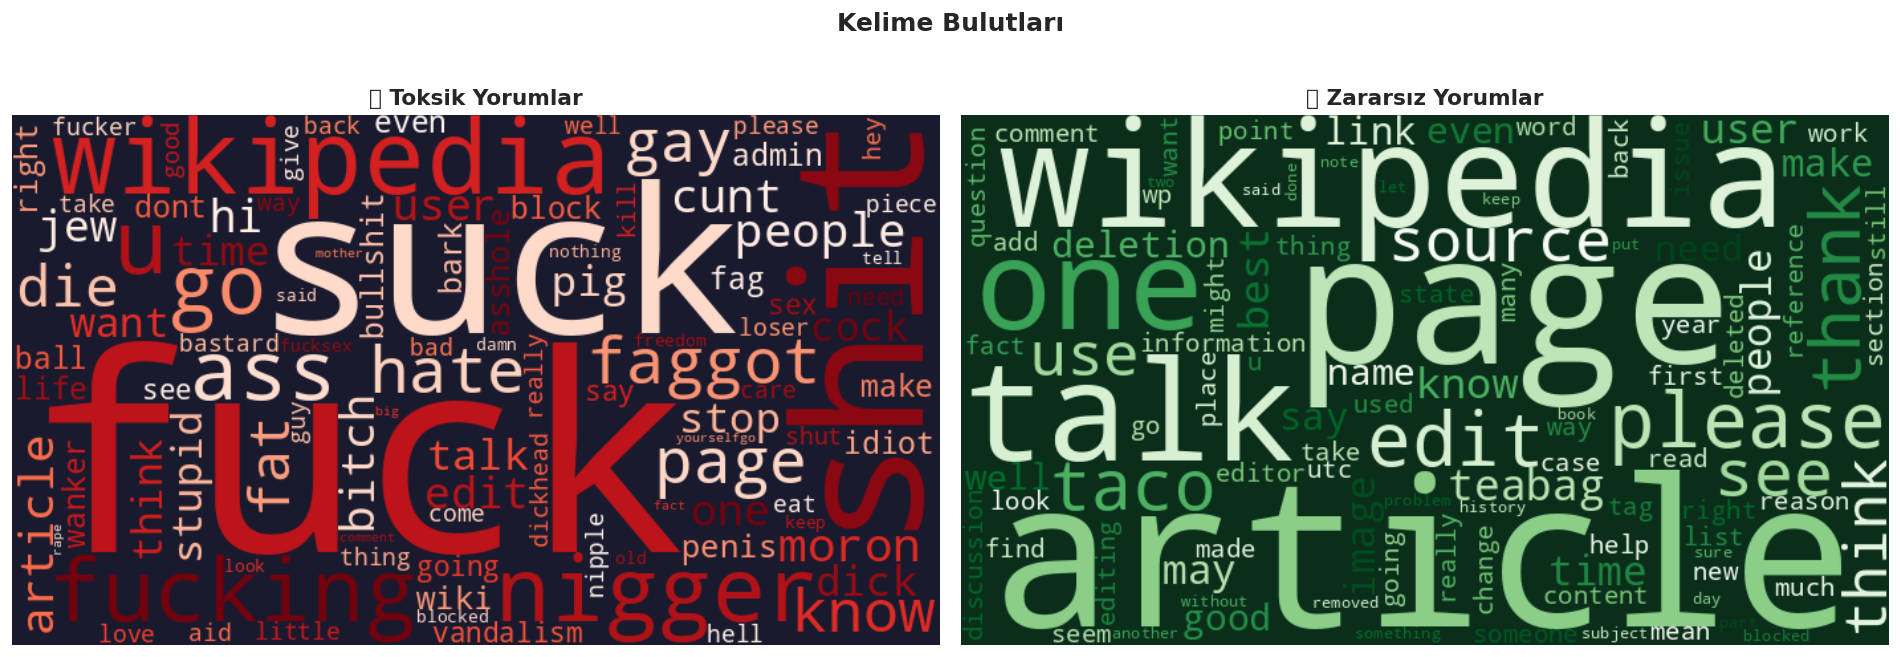

✅ 05_wordclouds.png


In [19]:
# GRAFİK 5 — Kelime Bulutları
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

toxic_text = ' '.join(df[df['toxic']==1]['cleaned_text'].dropna())
wc_toxic = WordCloud(width=700, height=400, background_color='#1a1a2e',
                     colormap='Reds', max_words=100, collocations=False)
wc_toxic.generate(toxic_text or 'no data')
axes[0].imshow(wc_toxic, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('🔴 Toksik Yorumlar', fontweight='bold', fontsize=13)

safe_sample = df[df['toxic']==0]['cleaned_text'].dropna().sample(
    min(5000, (df['toxic']==0).sum()), random_state=42)
safe_text = ' '.join(safe_sample)
wc_safe = WordCloud(width=700, height=400, background_color='#0a2e1a',
                    colormap='Greens', max_words=100, collocations=False)
wc_safe.generate(safe_text or 'no data')
axes[1].imshow(wc_safe, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('🟢 Zararsız Yorumlar', fontweight='bold', fontsize=13)

plt.suptitle('Kelime Bulutları', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '05_wordclouds.png'), bbox_inches='tight', facecolor='#111')
plt.show()
print('✅ 05_wordclouds.png')

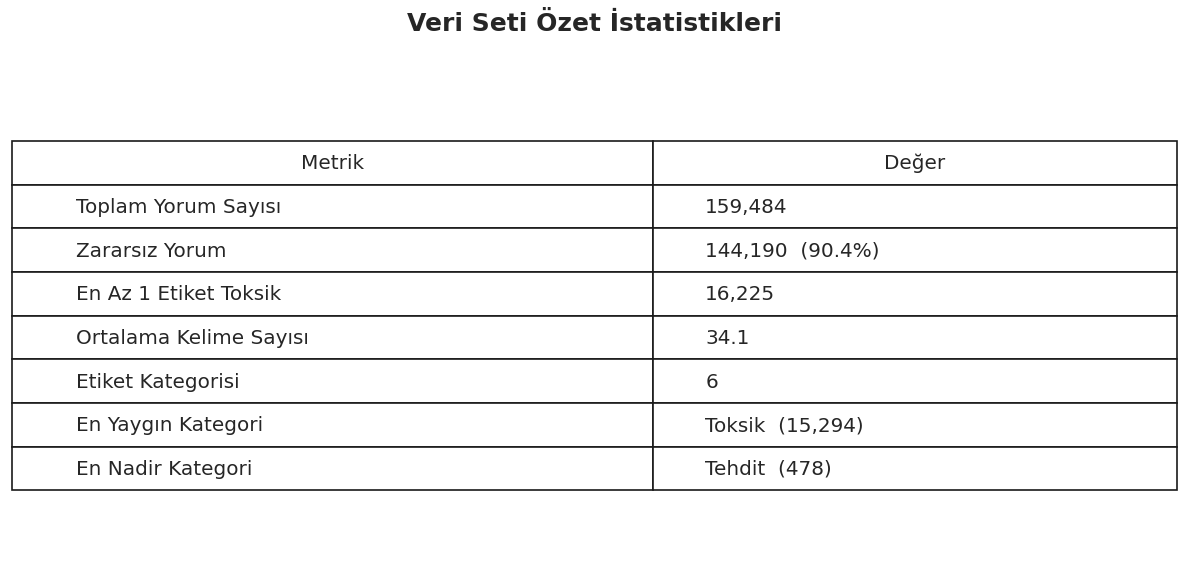

✅ 06_data_summary.png

🎉 Tüm dosyalar reports/ klasörüne kaydedildi. Artık Streamlit çalıştırabilirsin!


In [20]:
# GRAFİK 6 — Veri Seti Özet Tablosu
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')
summary_data = [
    ['Toplam Yorum Sayısı',           f'{len(df):,}'],
    ['Zararsız Yorum',                f'{(df["toxic"]==0).sum():,}  ({(df["toxic"]==0).mean():.1%})'],
    ['En Az 1 Etiket Toksik',         f'{(df[LABEL_COLS].sum(axis=1)>0).sum():,}'],
    ['Ortalama Kelime Sayısı',         f'{df["word_count"].mean():.1f}'],
    ['Etiket Kategorisi',             '6'],
    ['En Yaygın Kategori',            f'{LABEL_TR[df[LABEL_COLS].sum().idxmax()]}  ({df[LABEL_COLS].sum().max():,})'],
    ['En Nadir Kategori',             f'{LABEL_TR[df[LABEL_COLS].sum().idxmin()]}  ({df[LABEL_COLS].sum().min():,})'],
]
table = ax.table(cellText=summary_data, colLabels=['Metrik', 'Değer'],
                 cellLoc='left', loc='center', colWidths=[0.55, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.0)
ax.set_title('Veri Seti Özet İstatistikleri', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '06_data_summary.png'), bbox_inches='tight')
plt.show()
print('✅ 06_data_summary.png')
print()
print('🎉 Tüm dosyalar reports/ klasörüne kaydedildi. Artık Streamlit çalıştırabilirsin!')

In [22]:
from google.colab import files
import os, zipfile

# Zip oluştur
with zipfile.ZipFile('/content/toxicguard_reports.zip', 'w') as zf:
    reports_dir = '/content/toxicguard/reports'
    for root, dirs, fnames in os.walk(reports_dir):
        for fname in fnames:
            filepath = os.path.join(root, fname)
            zf.write(filepath, os.path.relpath(filepath, '/content/toxicguard'))

# İndir
files.download('/content/toxicguard_reports.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>